# Face Attributes Recognition Notebook

Bài này kết hợp **độ tuổi (age)**, **giới tính (gender)**, **chủng tộc (ethnicity)** dựa trên khuôn mặt.

Chúng ta sẽ:
1. Hướng dẫn lấy dataset từ Kaggle ( UTKFace )
2. Chuẩn bị thư mục dữ liệu
3. Tạo `Dataset` và `DataLoader`
4. Xây dựng model **VGG16**
5. Train nhanh 5 epoch để **demo** (có thể tăng sau)
6. Lưu model tốt nhất

> Lưu ý: notebook này viết theo kiểu dễ hiểu, tách nhiều cell để các bạn trong nhóm thay đổi cho từng mô hình khác nhau (ResNet, EfficientNet, MobileNet, GCN...).

In [ ]:
! pip install -q kaggle

In [6]:
import os
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
path = r'/content/drive/MyDrive/Nhom1_Py/Dataset'
os.listdir(path)

['utkface-new', 'fer2013', 'sample_img', 'ex_mobilenet', 'test_vgg']

In [3]:
# 2. Import thư viện cơ bản
import os, glob, random, time
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# !mkdir -p ~/.kaggle

In [ ]:
# !mv kaggle.json ~/.kaggle/

In [ ]:
# !chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# !kaggle datasets download -d msambare/fer2013 -p "/content/drive/MyDrive/Colab Notebooks/dataset" --force

In [ ]:
# !unzip "/content/drive/MyDrive/Colab Notebooks/dataset/fer2013.zip" -d "/content/drive/MyDrive/Colab Notebooks/dataset/fer2013"

In [ ]:
# !kaggle datasets download -d jangedoo/utkface-new -p "/content/drive/MyDrive/Colab Notebooks/dataset" --force

In [ ]:
# !unzip "/content/drive/MyDrive/Colab Notebooks/dataset/utkface-new.zip" -d "/content/drive/MyDrive/Colab Notebooks/dataset/utkface-new"

In [ ]:
#Hàm đếm ảnh (đặt tại đây là hợp lý)
def dem_anh_thu_muc(path):
    dem = 0
    for goc, thu_muc, files in os.walk(path):
        for f in files:
            if f.lower().endswith((".jpg", ".png", ".jpeg")):
                dem += 1
    return dem

train_folder = "/content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/train"
val_folder = "/content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/val"

print("Số ảnh train:", dem_anh_thu_muc(train_folder))
print("Số ảnh val:", dem_anh_thu_muc(val_folder))
print("Tổng:", dem_anh_thu_muc(train_folder) + dem_anh_thu_muc(val_folder))


Số ảnh train: 7857
Số ảnh val: 1956
Tổng: 9813


## 3. Chuẩn bị Dataset

Ở đây mình minh họa bằng **UTKFace** vì nó có đủ: age, gender, ethnicity trong tên file, ví dụ:

`22_0_0_20170104010223288.jpg.chip.jpg`
- 22 → tuổi (age)
- 0 → giới tính (gender) (0: male, 1: female)
- 0 → race (0: White, 1: Black, 2: Asian, 3: Indian, 4: Others)

Bạn có thể sửa lại mapping cho phù hợp đề tài của nhóm.

In [ ]:
def age_to_group5(age: int) -> int:
    """
    Chia tuổi thành 5 nhóm:
    0: 0-18
    1: 19-30
    2: 31-45
    3: 46-60
    4: 61+
    """
    if age <= 18:
        return 0
    elif age <= 30:
        return 1
    elif age <= 45:
        return 2
    elif age <= 60:
        return 3
    else:
        return 4


class UTKFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir       # Lưu đường dẫn thư mục gốc chứa ảnh.
        self.transform = transform     # Lưu các hàm biến đổi ảnh (nếu có).

        # Lấy tất cả định dạng ảnh phổ biến.
        exts = ["*.jpg", "*.jpeg", "*.png"]
        self.image_paths = []
        for ext in exts:
            # Tìm và gộp tất cả đường dẫn ảnh vào list.
            self.image_paths += glob.glob(os.path.join(root_dir, ext))

        # Sắp xếp để đảm bảo thứ tự file giống nhau mỗi lần chạy (quan trọng).
        self.image_paths.sort()

    def __len__(self):
        # Trả về tổng số lượng ảnh trong dataset.
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Lấy đường dẫn ảnh tại vị trí index.
        img_path = self.image_paths[idx]
        filename = os.path.basename(img_path) # Lấy tên file (ví dụ: 20_1_0_xxxx.jpg).

        # Phân tách tên file để lấy nhãn (theo format UTKFace: age_gender_race_date).
        parts = filename.split('_')
        if len(parts) < 3:
            raise ValueError(f"Filename không đúng format UTKFace: {filename}")

        age = int(parts[0])     # Nhãn tuổi.
        gender = int(parts[1])  # Nhãn giới tính (0: Nam, 1: Nữ).
        race = int(parts[2])    # Nhãn chủng tộc (0-4).

        # Load ảnh và chuyển về hệ màu RGB (tránh lỗi ảnh đen trắng/PNG).
        img = Image.open(img_path).convert("RGB")

        # Áp dụng các biến đổi ảnh (Resize, Normalize...) nếu có khai báo.
        if self.transform:
            img = self.transform(img)

        # Chuyển đổi tuổi cụ thể sang nhóm tuổi (Phân loại).
        age_cls = age_to_group5(age)

        # Trả về dictionary chứa ảnh và các nhãn tương ứng.
        return {
            'image': img,
            'age_cls': age_cls,
            'gender': gender,
            'race': race
        }

In [ ]:
# 3.1. Tạo transforms (các bước xử lý ảnh)

# Định nghĩa chuỗi xử lý cho tập Train (có tăng cường dữ liệu)
train_tfms = T.Compose([
    T.Resize((224, 224)),       # Đưa ảnh về kích thước chuẩn 224x224 (để khớp với mô hình ResNet/VGG).
    T.RandomHorizontalFlip(),   # Lật ảnh ngang ngẫu nhiên (Data Augmentation) để tránh học vẹt (Overfitting).
    T.ToTensor(),               # Chuyển ảnh từ [0, 255] sang Tensor [0, 1] và đổi chiều (C, H, W).
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Chuẩn hóa theo thông số ImageNet giúp model học nhanh hơn.
])

# Định nghĩa chuỗi xử lý cho tập Val (chỉ cần resize và chuẩn hóa, không lật ảnh)
val_tfms = T.Compose([
    T.Resize((224, 224)),       # Resize về cùng kích thước với tập Train.
    T.ToTensor(),               # Chuyển sang Tensor.
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Chuẩn hóa giống tập Train.
])

# TODO: đổi đường dẫn này theo máy của bạn
train_dir = "/content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/train"
val_dir = "/content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/val"

# Kiểm tra đường dẫn tồn tại trước khi tạo Dataset để tránh lỗi Crash chương trình
if os.path.exists(train_dir):
    train_dataset = UTKFaceDataset(train_dir, transform=train_tfms) # Khởi tạo dataset train với augmentation.
else:
    train_dataset = None

if os.path.exists(val_dir):
    val_dataset = UTKFaceDataset(val_dir, transform=val_tfms)       # Khởi tạo dataset val (không augmentation).
else:
    val_dataset = None

train_dataset # In biến này ra dòng cuối cùng để kiểm tra xem dataset đã tạo thành công chưa.

In [ ]:
batch_size = 32 # Số lượng mẫu (ảnh) đưa vào model trong mỗi lần huấn luyện.

if train_dataset is not None:
    # Tạo DataLoader cho tập huấn luyện, để trộn dữ liệu mỗi epoch, dùng 2 luồng để load dữ liệu nhanh hơn.
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
else:
    # Nếu không có dataset thì không tạo loader.
    train_loader = None

if val_dataset is not None:
    # DataLoader cho tập validation, đánh giá không cần trộn dữ liệu.
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
else:
    val_loader = None

# In ra train_loader để kiểm tra.
train_loader

## 4. Xây dựng model VGG16 đa nhiệm (multi-head)

Ý tưởng: dùng **1 backbone VGG** để trích đặc trưng khuôn mặt → tách ra 3 head nhỏ:
- Head 1: Age-group (5 lớp)
- Head 2: Gender (2 lớp)
- Head 3: Race/Ethnicity (5 lớp)

In [4]:
class VGGMultiHead(nn.Module):
    def __init__(self, num_age=5, num_gender=2, num_race=5):
        super().__init__()

        # Load mô hình VGG16 đã được huấn luyện sẵn, dùng làm backbone để trích xuất đặc trưng từ ảnh.
        base = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Phần các lớp tích chập (convolution) của VGG16.
        # Đây là nơi mô hình học và rút ra đặc trưng quan trọng từ ảnh.
        self.features = base.features

        # Lớp trung bình hoá không gian cuối của VGG16.
        self.avgpool = base.avgpool

        # Số lượng đầu vào của lớp FC đầu tiên.
        in_feats = base.classifier[0].in_features

        # Khối fully-connected dùng chung cho cả 3 nhiệm vụ, học đặc trưng.
        self.fc = nn.Sequential(
            nn.Linear(in_feats, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, 1024),
            nn.ReLU(True),
        )

        # Ba nhánh dự đoán riêng (multi-head)
        self.age_head = nn.Linear(1024, num_age)
        self.gender_head = nn.Linear(1024, num_gender)
        self.race_head = nn.Linear(1024, num_race)

    def forward(self, x):
        # Bước 1: Trích đặc trưng bằng backbone VGG16
        x = self.features(x)

        # Bước 2: Thu gọn không gian bằng avgpool
        x = self.avgpool(x)

        # Bước 3: Làm phẳng tensor để đưa vào các lớp FC
        x = torch.flatten(x, 1)

        # Bước 4: Qua khối FC dùng chung
        x = self.fc(x)

        # Bước 5: Mỗi head đưa ra một dự đoán riêng
        age_logits = self.age_head(x)
        gender_logits = self.gender_head(x)
        race_logits = self.race_head(x)

        return age_logits, gender_logits, race_logits

# Khởi tạo mô hình
model = VGGMultiHead().to(device)
model


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 92.9MB/s]


VGGMultiHead(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, d

## 5. Hàm train 5 epoch (demo)
- Mình viết kiểu **rõ ràng, dễ chỉnh** cho nhóm bạn.
- Loss tổng = `loss_age + loss_gender + loss_race` (có thể gán trọng số nếu muốn).

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion_age, criterion_gender, criterion_race):
    # Đặt mô hình về chế độ train (bật dropout, batchnorm…)
    model.train()

    running_loss = 0.0  # biến tích lũy loss của cả epoch

    # Duyệt từng batch trong DataLoader
    for batch in loader:
        # Lấy ảnh và các nhãn tương ứng, đưa lên GPU/CPU
        imgs = batch['image'].to(device)
        age = batch['age_cls'].to(device)
        gender = batch['gender'].to(device)
        race = batch['race'].to(device)

        # Xoá gradient cũ để tránh cộng dồn
        optimizer.zero_grad()

        # Cho ảnh qua mô hình, trả về 3 kết quả dự đoán
        age_logits, gender_logits, race_logits = model(imgs)

        # Tính từng loss riêng cho 3 nhiệm vụ
        loss_age = criterion_age(age_logits, age)
        loss_gender = criterion_gender(gender_logits, gender)
        loss_race = criterion_race(race_logits, race)

        # Loss tổng = cộng 3 loss (mô hình học đa nhiệm)
        loss = loss_age + loss_gender + loss_race

        # Lan truyền ngược để tính gradient
        loss.backward()

        # Cập nhật trọng số mô hình
        optimizer.step()

        # Cộng dồn loss theo số lượng mẫu
        running_loss += loss.item() * imgs.size(0)

    # Trả về loss trung bình của cả epoch
    return running_loss / len(loader.dataset)


In [ ]:
@torch.no_grad()
# Tắt chế độ tính gradient.
def eval_one_epoch(model, loader, criterion_age, criterion_gender, criterion_race):
    model.eval()
    # Đặt mô hình sang chế độ đánh giá (tắt dropout, batchnorm chạy ở mode eval).

    running_loss = 0.0
    correct_age = 0
    correct_gender = 0
    correct_race = 0
    total = 0   # tổng số mẫu để tính accuracy

    # Duyệt từng batch dữ liệu validation
    for batch in loader:
        imgs = batch['image'].to(device)
        age = batch['age_cls'].to(device)
        gender = batch['gender'].to(device)
        race = batch['race'].to(device)

        # Cho ảnh qua mô hình để lấy dự đoán
        age_logits, gender_logits, race_logits = model(imgs)

        # Tính loss cho từng nhiệm vụ
        loss_age = criterion_age(age_logits, age)
        loss_gender = criterion_gender(gender_logits, gender)
        loss_race = criterion_race(race_logits, race)

        # Loss tổng dùng để đánh giá mức độ sai chung
        loss = loss_age + loss_gender + loss_race

        # Cộng dồn loss theo số lượng mẫu
        running_loss += loss.item() * imgs.size(0)

        # -----------------------
        # Tính accuracy cho từng task
        # .max(1) → lấy class có xác suất cao nhất
        # -----------------------
        _, age_pred = age_logits.max(1)
        _, gender_pred = gender_logits.max(1)
        _, race_pred = race_logits.max(1)

        # Đếm số dự đoán đúng
        correct_age += (age_pred == age).sum().item()
        correct_gender += (gender_pred == gender).sum().item()
        correct_race += (race_pred == race).sum().item()

        total += imgs.size(0)

    # Tính loss trung bình của cả epoch
    avg_loss = running_loss / len(loader.dataset)

    # Tính accuracy từng nhiệm vụ
    age_acc = correct_age / total
    gender_acc = correct_gender / total
    race_acc = correct_race / total

    # Trả về loss + 3 độ chính xác
    return avg_loss, age_acc, gender_acc, race_acc


In [ ]:
num_epochs = 5   # số lần lặp toàn bộ dữ liệu train

# Khai báo hàm loss cho 3 nhiệm vụ (tuổi / giới tính / chủng tộc)
# Vì đây là bài toán phân loại → dùng CrossEntropyLoss
criterion_age = nn.CrossEntropyLoss()
criterion_gender = nn.CrossEntropyLoss()
criterion_race = nn.CrossEntropyLoss()

# Chọn optimizer Adam và đặt learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

best_val_loss = float('inf')  # lưu loss tốt nhất để chọn model tốt nhất
best_state = None            # lưu trọng số tốt nhất

# Kiểm tra nếu đã có train_loader và val_loader
if train_loader is not None and val_loader is not None:
    for epoch in range(num_epochs):

        # Huấn luyện một epoch → trả về train_loss trung bình
        train_loss = train_one_epoch(
            model, train_loader, optimizer,
            criterion_age, criterion_gender, criterion_race
        )

        # Đánh giá trên tập validation → trả về loss + accuracy từng task
        val_loss, age_acc, gender_acc, race_acc = eval_one_epoch(
            model, val_loader,
            criterion_age, criterion_gender, criterion_race
        )

        # In kết quả của epoch
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"age_acc={age_acc:.3f} | gender_acc={gender_acc:.3f} | race_acc={race_acc:.3f}")

        # Lưu model tốt nhất dựa trên validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
else:
    # Nếu chưa có dữ liệu train/val thì báo lỗi
    print("Chưa có dữ liệu train/val. Hãy tải UTKFace rồi đặt vào data/...")


Epoch 1/5 | train_loss=1.9933 | val_loss=1.6162 | age_acc=0.718 | gender_acc=0.863 | race_acc=0.768
Epoch 2/5 | train_loss=1.3840 | val_loss=1.3812 | age_acc=0.748 | gender_acc=0.874 | race_acc=0.807
Epoch 3/5 | train_loss=1.1614 | val_loss=1.2821 | age_acc=0.759 | gender_acc=0.887 | race_acc=0.838
Epoch 4/5 | train_loss=0.9208 | val_loss=1.3383 | age_acc=0.773 | gender_acc=0.896 | race_acc=0.814
Epoch 5/5 | train_loss=0.7876 | val_loss=1.4042 | age_acc=0.764 | gender_acc=0.883 | race_acc=0.801


In [ ]:
# 7. Lưu model tốt nhất
if best_state is not None:
    # Tạo thư mục 'checkpoints' nếu chưa tồn tại
    os.makedirs("checkpoints", exist_ok=True)

    # Lưu trọng số tốt nhất của mô hình vào file .pth
    torch.save(best_state, "checkpoints/vgg_multihead_best.pth")

    print("Đã lưu model tốt nhất tại checkpoints/vgg_multihead_best.pth")
else:
    # Trường hợp không có model để lưu (thường do chưa train hoặc thiếu dữ liệu)
    print("Chưa có model để lưu (có thể chưa train được do thiếu dữ liệu)")


Đã lưu model tốt nhất tại checkpoints/vgg_multihead_best.pth


In [ ]:
# Sao chép file model đã lưu trong thư mục checkpoints
# sang Google Drive để lưu trữ hoặc sử dụng sau này.
!cp "checkpoints/vgg_multihead_best.pth" "/content/drive/MyDrive/Nhom1_Py/"



📂 Số ảnh tìm thấy: 7


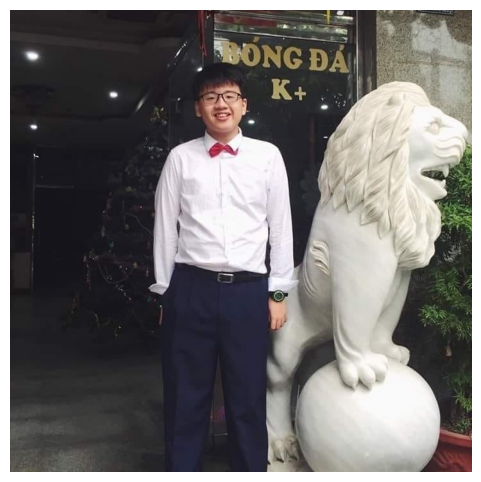

📌 Image: 470201906_597426899414142_3727251411426595894_n.jpg
------------------------------------------
╒═══════════╤══════════════╤═══════════════╕
│ Label     │ Prediction   │   Probability │
╞═══════════╪══════════════╪═══════════════╡
│ Age Group │ 4            │        0.894  │
├───────────┼──────────────┼───────────────┤
│ Gender    │ Male         │        0.9999 │
├───────────┼──────────────┼───────────────┤
│ Race      │ White        │        0.9711 │
╘═══════════╧══════════════╧═══════════════╛




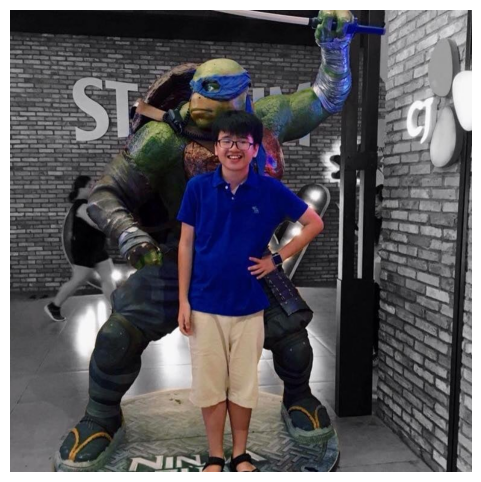

📌 Image: 470208342_597426946080804_2590862820287107676_n.jpg
------------------------------------------
╒═══════════╤══════════════╤═══════════════╕
│ Label     │ Prediction   │   Probability │
╞═══════════╪══════════════╪═══════════════╡
│ Age Group │ 4            │        0.9378 │
├───────────┼──────────────┼───────────────┤
│ Gender    │ Male         │        0.9809 │
├───────────┼──────────────┼───────────────┤
│ Race      │ White        │        0.6413 │
╘═══════════╧══════════════╧═══════════════╛




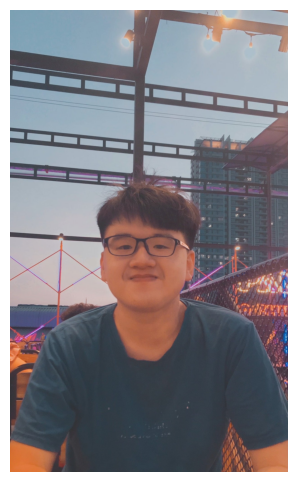

📌 Image: 470175316_597427142747451_6324105389662271905_n.jpg
------------------------------------------
╒═══════════╤══════════════╤═══════════════╕
│ Label     │ Prediction   │   Probability │
╞═══════════╪══════════════╪═══════════════╡
│ Age Group │ 0            │        0.4508 │
├───────────┼──────────────┼───────────────┤
│ Gender    │ Male         │        0.9487 │
├───────────┼──────────────┼───────────────┤
│ Race      │ White        │        0.863  │
╘═══════════╧══════════════╧═══════════════╛




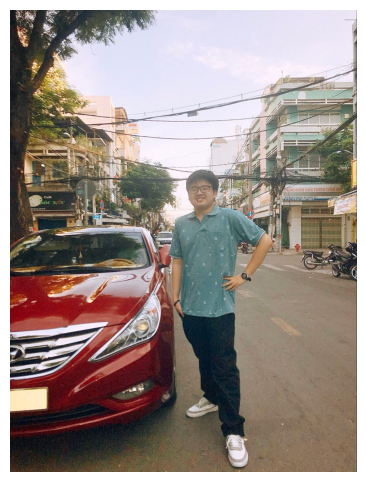

📌 Image: 472777449_615057497651082_4052188363070806310_n.jpg
------------------------------------------
╒═══════════╤══════════════╤═══════════════╕
│ Label     │ Prediction   │   Probability │
╞═══════════╪══════════════╪═══════════════╡
│ Age Group │ 4            │        0.8068 │
├───────────┼──────────────┼───────────────┤
│ Gender    │ Male         │        0.8149 │
├───────────┼──────────────┼───────────────┤
│ Race      │ White        │        0.9912 │
╘═══════════╧══════════════╧═══════════════╛




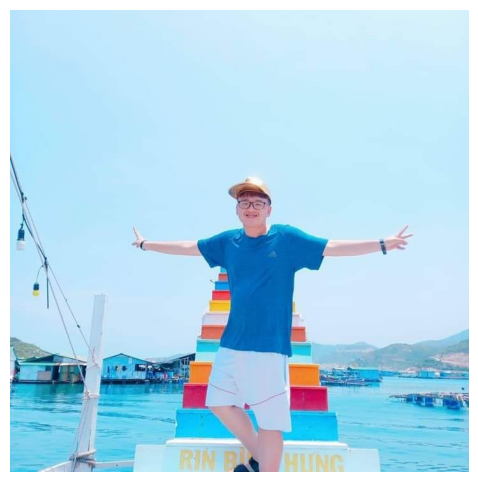

📌 Image: 474484982_623786933444805_4927778197386314280_n.jpg
------------------------------------------
╒═══════════╤══════════════╤═══════════════╕
│ Label     │ Prediction   │   Probability │
╞═══════════╪══════════════╪═══════════════╡
│ Age Group │ 0            │        0.6748 │
├───────────┼──────────────┼───────────────┤
│ Gender    │ Male         │        0.9363 │
├───────────┼──────────────┼───────────────┤
│ Race      │ White        │        0.946  │
╘═══════════╧══════════════╧═══════════════╛




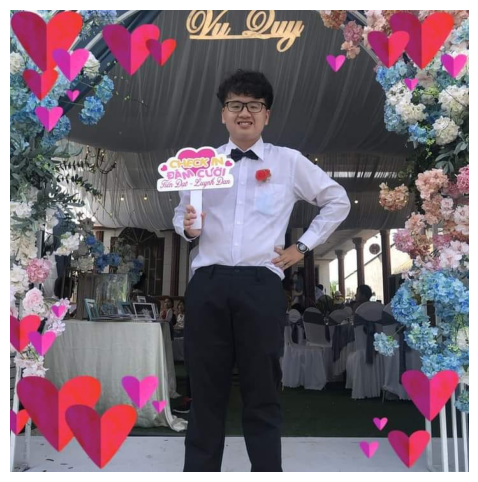

📌 Image: 475546055_629510066205825_4810075335321661699_n.jpg
------------------------------------------
╒═══════════╤══════════════╤═══════════════╕
│ Label     │ Prediction   │   Probability │
╞═══════════╪══════════════╪═══════════════╡
│ Age Group │ 0            │        0.7375 │
├───────────┼──────────────┼───────────────┤
│ Gender    │ Male         │        0.9849 │
├───────────┼──────────────┼───────────────┤
│ Race      │ White        │        0.6749 │
╘═══════════╧══════════════╧═══════════════╛




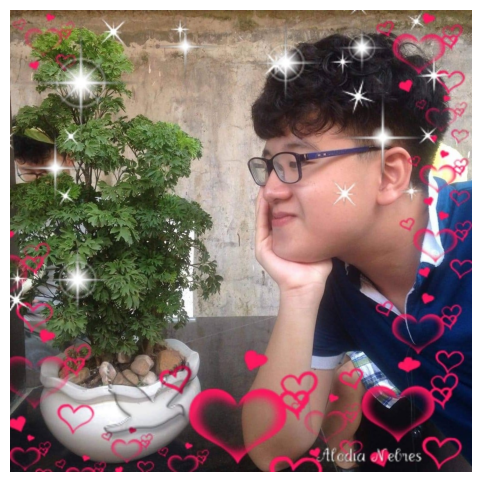

📌 Image: 470200557_597427036080795_7408959278894115940_n.jpg
------------------------------------------
╒═══════════╤══════════════╤═══════════════╕
│ Label     │ Prediction   │   Probability │
╞═══════════╪══════════════╪═══════════════╡
│ Age Group │ 4            │        0.958  │
├───────────┼──────────────┼───────────────┤
│ Gender    │ Female       │        0.9985 │
├───────────┼──────────────┼───────────────┤
│ Race      │ Black        │        0.3567 │
╘═══════════╧══════════════╧═══════════════╛




In [7]:
import torch
import torch.nn.functional as F
from PIL import Image
import glob
import os
from torchvision import transforms
import matplotlib.pyplot as plt
from tabulate import tabulate

# ============================
# Load model
# ============================
# Khởi tạo mô hình giống lúc train
model = VGGMultiHead()  # thay bằng class mô hình đa nhiệm của bạn

# Load trọng số đã train tốt nhất từ Google Drive
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/Nhom1_Py/vgg_multihead_best.pth",
    map_location="cuda"          # Load trực tiếp lên GPU
))

model.eval()                    # Đưa mô hình về chế độ dự đoán (eval)
model.to("cuda")                # Chạy mô hình trên GPU

# ============================
# Transform hình
# ============================
# Các bước xử lý ảnh giống hệt lúc train:
# - Resize về 224x224
# - Chuẩn hoá theo mean/std của ImageNet
# - Chuyển thành tensor
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # Giá trị chuẩn của ImageNet
        std=[0.229, 0.224, 0.225]
    )
])

# Danh sách chủng tộc tương ứng với các lớp dự đoán
race_dict = ["White", "Black", "Asian", "Indian", "Others"]

# ============================
# Predict
# ============================
def predict_image(model, img_path):

    # Mở ảnh và chuyển sang RGB (tránh lỗi khi ảnh là L hoặc RGBA)
    img = Image.open(img_path).convert("RGB")

    # Áp dụng transform + thêm batch dimension
    img_tensor = transform(img).unsqueeze(0).to("cuda")

    # Dự đoán không tính gradient → tiết kiệm bộ nhớ
    with torch.no_grad():
        age_out, gender_out, race_out = model(img_tensor)

    # Chuyển logits thành xác suất
    age_prob = F.softmax(age_out, dim=1).cpu().numpy()[0]
    gender_prob = F.softmax(gender_out, dim=1).cpu().numpy()[0]
    race_prob = F.softmax(race_out, dim=1).cpu().numpy()[0]

    # Lấy nhãn dự đoán có xác suất lớn nhất
    age_label = age_prob.argmax()
    gender_label = "Male" if gender_prob.argmax() == 0 else "Female"
    race_label = race_dict[race_prob.argmax()]

    # Trả về nhãn + xác suất để in ra bảng
    return age_label, gender_label, race_label, age_prob, gender_prob, race_prob


# ============================
# Scan hình và in kết quả
# ============================
folder_path = "/content/drive/MyDrive/Nhom1_Py/Dataset/sample_img"

# Lấy toàn bộ file ảnh trong folder
image_files = glob.glob(os.path.join(folder_path, "*"))

print("\n📂 Số ảnh tìm thấy:", len(image_files))

for img_path in image_files:

    # Chạy dự đoán cho từng ảnh
    age, gender, race, age_prob, gender_prob, race_prob = predict_image(model, img_path)

    # Hiển thị ảnh
    img = Image.open(img_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # In kết quả dự đoán theo bảng cho dễ đọc
    print("==========================================")
    print(f"📌 Image: {os.path.basename(img_path)}")
    print("------------------------------------------")

    table_main = [
        ["Age Group", age, f"{age_prob[age]:.4f}"],        # Xác suất tuổi
        ["Gender", gender,
         f"{gender_prob[0] if gender=='Male' else gender_prob[1]:.4f}"],  # Xác suất giới tính
        ["Race", race, f"{race_prob[race_dict.index(race)]:.4f}"],        # Xác suất chủng tộc
    ]

    print(tabulate(table_main, headers=["Label", "Prediction", "Probability"], tablefmt="fancy_grid"))
    print("==========================================\n\n")
